# Hotel Booking Cancellation Prediction


## Setup and Data Cleaning Utilities


In [1]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split


DATA_CANDIDATES = [Path("data/raw/hotel_bookings.csv"), Path("data/hotel_bookings.csv")]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
LEAKAGE_COLUMNS = [
    "reservation_status",
    "reservation_status_date",
    "assigned_room_type",
]


def load_raw_data():
    return pd.read_csv(DATA_PATH)


def clean_booking_data(df):
    cleaned_df = df.copy()
    cleaned_df["children"] = cleaned_df["children"].fillna(0).astype(int)
    cleaned_df["country"] = cleaned_df["country"].fillna("Unknown")
    cleaned_df["agent"] = (
        cleaned_df["agent"].astype("Int64").astype("string").fillna("No agent")
    )
    cleaned_df["company"] = (
        cleaned_df["company"].astype("Int64").astype("string").fillna("No company")
    )

    cleaned_df["total_guests"] = (
        cleaned_df["adults"] + cleaned_df["children"] + cleaned_df["babies"]
    )
    cleaned_df["total_stays"] = (
        cleaned_df["stays_in_weekend_nights"] + cleaned_df["stays_in_week_nights"]
    )
    cleaned_df["is_family"] = (
        (cleaned_df["children"] > 0) | (cleaned_df["babies"] > 0)
    ).astype(int)

    cleaned_df = cleaned_df[
        (cleaned_df["total_guests"] > 0) & (cleaned_df["adr"] >= 0)
    ].copy()
    return cleaned_df.drop(columns=LEAKAGE_COLUMNS)


def load_cleaned_data():
    return clean_booking_data(load_raw_data())


def take_stratified_sample(df, sample_size, random_state=42):
    if sample_size is None or sample_size >= len(df):
        return df.copy()
    sample, _ = train_test_split(
        df,
        train_size=sample_size,
        stratify=df["is_canceled"],
        random_state=random_state,
    )
    return sample.copy()


## 1. Exploratory Data Analysis

Dataset shape: (119390, 32)

Numerical summary
                              count    mean     std   min    25%    50%  \
lead_time                  119390.0  104.01  106.86  0.00  18.00  69.00   
adr                        119390.0  101.83   50.54 -6.38  69.29  94.58   
stays_in_weekend_nights    119390.0    0.93    1.00  0.00   0.00   1.00   
stays_in_week_nights       119390.0    2.50    1.91  0.00   1.00   2.00   
adults                     119390.0    1.86    0.58  0.00   2.00   2.00   
children                   119386.0    0.10    0.40  0.00   0.00   0.00   
babies                     119390.0    0.01    0.10  0.00   0.00   0.00   
booking_changes            119390.0    0.22    0.65  0.00   0.00   0.00   
total_of_special_requests  119390.0    0.57    0.79  0.00   0.00   0.00   

                             75%     max  
lead_time                  160.0   737.0  
adr                        126.0  5400.0  
stays_in_weekend_nights      2.0    19.0  
stays_in_week_nights         3

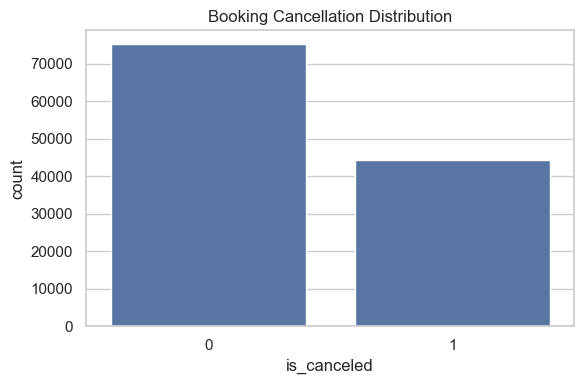

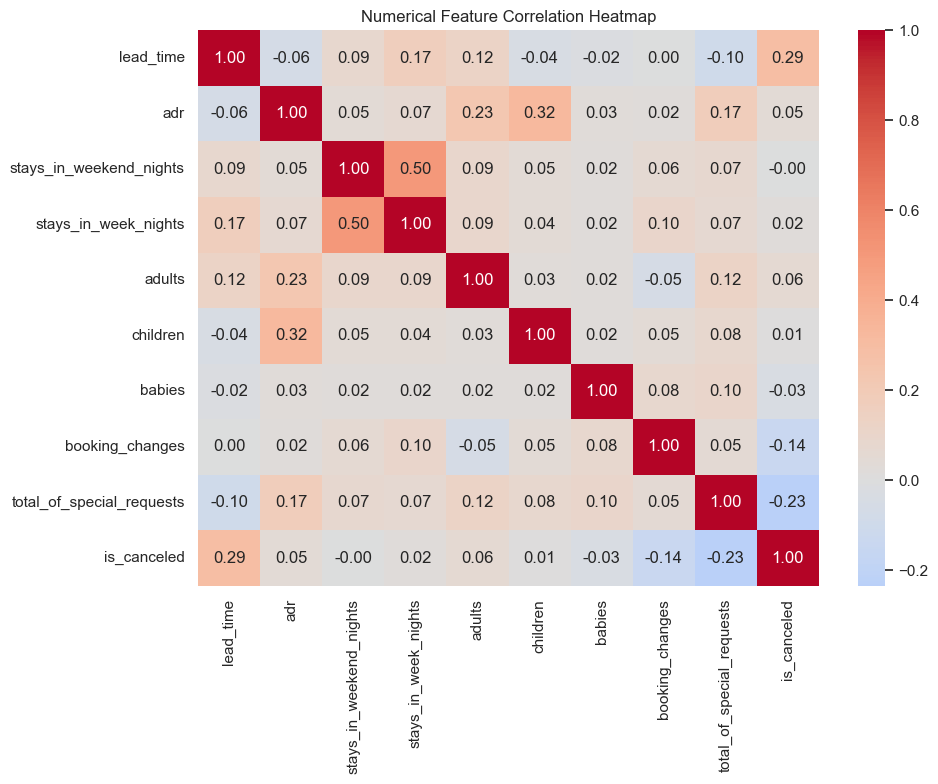

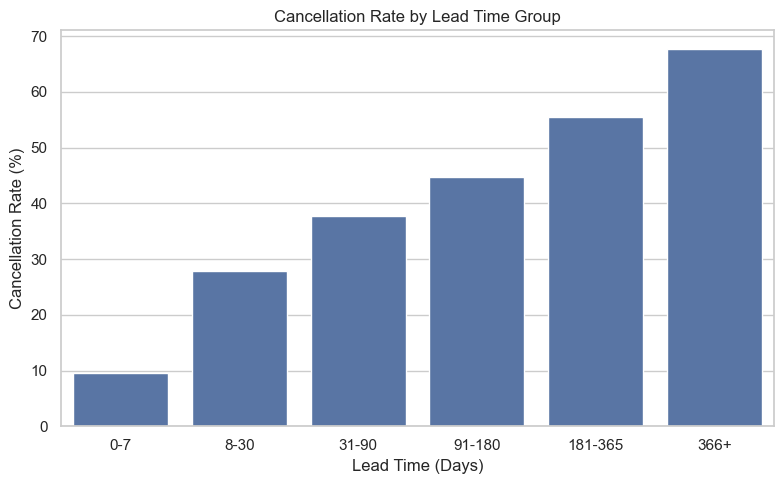

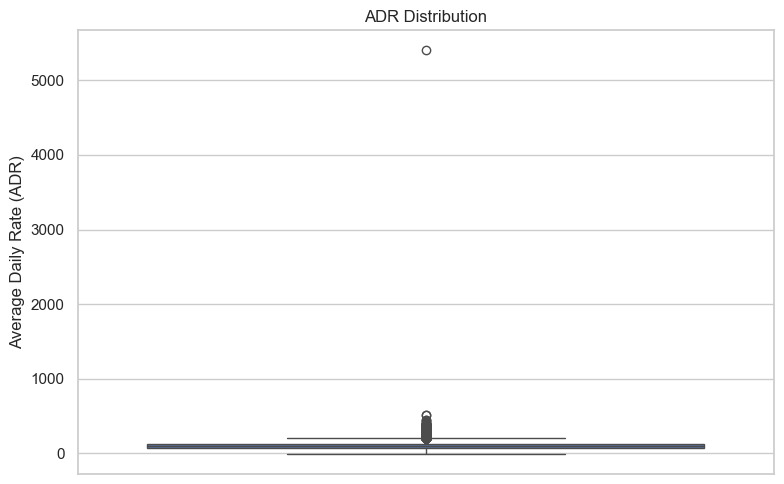

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = load_raw_data()

numerical_columns = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "booking_changes",
    "total_of_special_requests",
]
rate_columns = ["hotel", "deposit_type", "customer_type", "market_segment"]

print("Dataset shape:", df.shape)
print("\nNumerical summary")
print(df[numerical_columns].describe().T.round(2))

print("\nMissing values")
print(df.isnull().sum().loc[lambda values: values > 0].sort_values(ascending=False))
print("\nDuplicate rows:", df.duplicated().sum())

total_guests = df["adults"] + df["children"].fillna(0) + df["babies"]
total_stays = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
print("Zero total guests:", (total_guests == 0).sum())
print("Zero total stay nights:", (total_stays == 0).sum())
print("Negative ADR:", (df["adr"] < 0).sum())

q1 = df["adr"].quantile(0.25)
q3 = df["adr"].quantile(0.75)
iqr = q3 - q1
adr_outliers = df[(df["adr"] < q1 - 1.5 * iqr) | (df["adr"] > q3 + 1.5 * iqr)]
print("ADR outliers by IQR:", len(adr_outliers))

target_summary = pd.DataFrame(
    {
        "count": df["is_canceled"].value_counts().sort_index(),
        "percentage": (
            df["is_canceled"].value_counts().sort_index() / len(df) * 100
        ).round(2),
    }
)
print("\nCancellation distribution")
print(target_summary)
print(
    "\nCancellation is about 37%, so it is not severely imbalanced, "
    "but stratified validation is appropriate."
)

for column in rate_columns:
    rates = df.groupby(column)["is_canceled"].mean().mul(100).round(2)
    print(f"\nCancellation rate by {column}")
    print(rates)

lead_time_groups = pd.cut(
    df["lead_time"],
    bins=[-1, 7, 30, 90, 180, 365, float("inf")],
    labels=["0-7", "8-30", "31-90", "91-180", "181-365", "366+"],
)
lead_time_rate = (
    df.assign(lead_time_group=lead_time_groups)
    .groupby("lead_time_group", observed=False)["is_canceled"]
    .mean()
    .mul(100)
    .round(2)
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_canceled")
plt.title("Booking Cancellation Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
correlation = df[numerical_columns + ["is_canceled"]].corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Numerical Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x=lead_time_rate.index, y=lead_time_rate.values)
plt.title("Cancellation Rate by Lead Time Group")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y="adr")
plt.title("ADR Distribution")
plt.ylabel("Average Daily Rate (ADR)")
plt.tight_layout()
plt.show()


## 2. Data Preprocessing Summary

In [3]:
import pandas as pd


raw_df = load_raw_data()
cleaned_df = clean_booking_data(raw_df)

summary = pd.Series(
    {
        "raw_rows": len(raw_df),
        "cleaned_rows": len(cleaned_df),
        "removed_invalid_rows": len(raw_df) - len(cleaned_df),
        "raw_cancellation_rate_percent": raw_df["is_canceled"].mean() * 100,
        "cleaned_cancellation_rate_percent": cleaned_df["is_canceled"].mean() * 100,
        "duplicate_rows_kept_for_review": raw_df.duplicated().sum(),
        "remaining_zero_night_bookings": (cleaned_df["total_stays"] == 0).sum(),
        "remaining_missing_values": cleaned_df.isnull().sum().sum(),
    }
)

print("Preprocessing summary")
print(summary.round(2))

print("\nCleaning decisions")
print("- Filled missing children values with 0")
print("  Missing children values are treated as no children in the reservation.")
print("- Filled missing country, agent, and company values with labels")
print("- Created total_guests, total_stays, and is_family")
print("- Removed rows with zero guests or negative ADR")
print("- Kept identical rows because there is no booking ID to prove duplication")
print("- Dropped leakage columns:", LEAKAGE_COLUMNS)
print("- Encoding and scaling are applied in the modeling pipeline")


Preprocessing summary
raw_rows                             119390.00
cleaned_rows                         119209.00
removed_invalid_rows                    181.00
raw_cancellation_rate_percent            37.04
cleaned_cancellation_rate_percent        37.08
duplicate_rows_kept_for_review        31994.00
remaining_zero_night_bookings           645.00
remaining_missing_values                  0.00
dtype: float64

Cleaning decisions
- Filled missing children values with 0
  Missing children values are treated as no children in the reservation.
- Filled missing country, agent, and company values with labels
- Created total_guests, total_stays, and is_family
- Removed rows with zero guests or negative ADR
- Kept identical rows because there is no booking ID to prove duplication
- Dropped leakage columns: ['reservation_status', 'reservation_status_date', 'assigned_room_type']
- Encoding and scaling are applied in the modeling pipeline


## 3. Classification Modeling

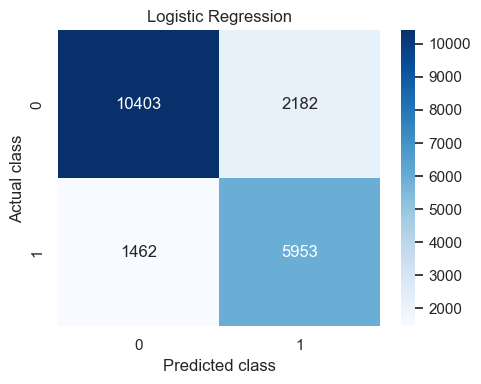

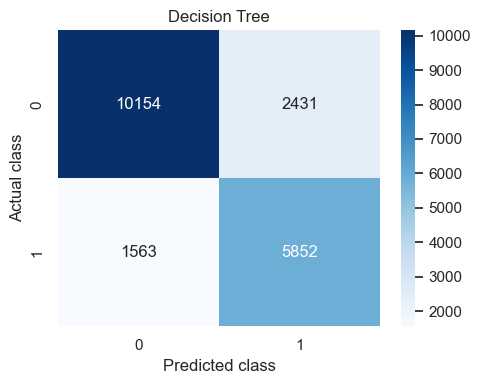

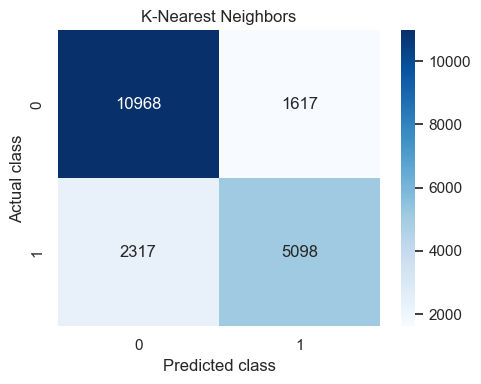

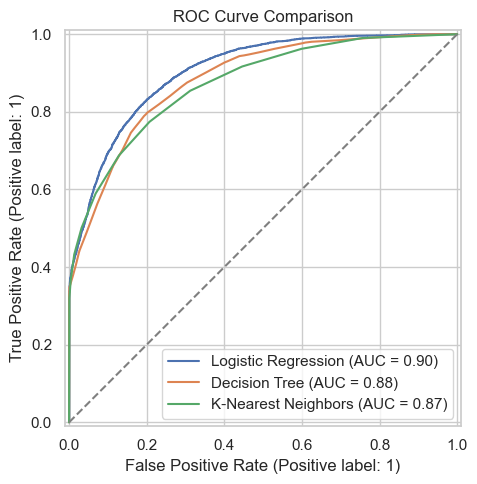

5-Fold cross-validation results
              model  accuracy  balanced_accuracy  precision  recall  f1_score  roc_auc
Logistic Regression    0.8178             0.8147     0.7320  0.8028    0.7657   0.9046
      Decision Tree    0.8003             0.7980     0.7067  0.7892    0.7456   0.8809
K-Nearest Neighbors    0.8033             0.7795     0.7594  0.6875    0.7215   0.8733

Best model based on F1-score: Logistic Regression

Decision Tree feature importance
                    feature  importance
               deposit_type      0.4190
                      agent      0.2652
                  lead_time      0.1007
                    country      0.0909
  total_of_special_requests      0.0635
required_car_parking_spaces      0.0389
            booking_changes      0.0199
                    company      0.0020
          arrival_date_year      0.0000
         arrival_date_month      0.0000


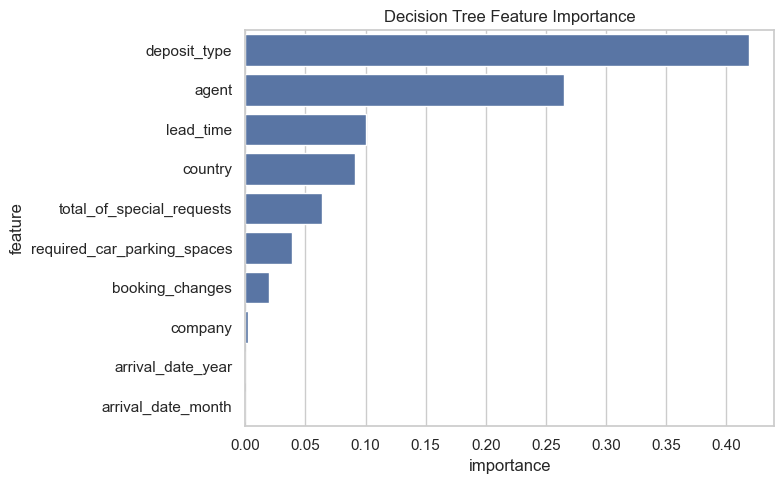

In [4]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


RANDOM_STATE = 42
df = take_stratified_sample(load_cleaned_data(), 20_000, RANDOM_STATE)
X = df.drop(columns="is_canceled")
y = df["is_canceled"]

categorical_columns = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()

# Scaling keeps distance-based KNN and coefficient-based models comparable.
preprocessor = ColumnTransformer(
    [
        (
            "numeric",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numerical_columns,
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_columns,
        ),
    ]
)

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=2000, solver="liblinear"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=11),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
roc_results = {}

for model_name, model in models.items():
    fold_results = []
    actual_values = []
    predicted_values = []
    probability_values = []

    for train_index, test_index in cv.split(X, y):
        pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
        pipeline.fit(X.iloc[train_index], y.iloc[train_index])
        prediction = pipeline.predict(X.iloc[test_index])
        probability = pipeline.predict_proba(X.iloc[test_index])[:, 1]
        actual = y.iloc[test_index]

        fold_results.append(
            {
                "accuracy": accuracy_score(actual, prediction),
                "balanced_accuracy": balanced_accuracy_score(actual, prediction),
                "precision": precision_score(actual, prediction, zero_division=0),
                "recall": recall_score(actual, prediction, zero_division=0),
                "f1_score": f1_score(actual, prediction, zero_division=0),
                "roc_auc": roc_auc_score(actual, probability),
            }
        )
        actual_values.extend(actual)
        predicted_values.extend(prediction)
        probability_values.extend(probability)

    mean_scores = pd.DataFrame(fold_results).mean()
    results.append({"model": model_name, **mean_scores.to_dict()})
    roc_results[model_name] = (actual_values, probability_values)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(actual_values, predicted_values),
        annot=True,
        fmt="d",
        cmap="Blues",
    )
    plt.title(model_name)
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
for model_name, (actual, probability) in roc_results.items():
    RocCurveDisplay.from_predictions(actual, probability, name=model_name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_title("ROC Curve Comparison")
fig.tight_layout()
plt.show()

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)
print("5-Fold cross-validation results")
print(results_df.round(4).to_string(index=False))
print("\nBest model based on F1-score:", results_df.iloc[0]["model"])

tree_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("model", models["Decision Tree"])]
)
tree_pipeline.fit(X, y)

feature_names = tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": tree_pipeline.named_steps["model"].feature_importances_,
    }
)

for column in categorical_columns:
    importance_df.loc[
        importance_df["feature"].str.startswith(f"categorical__{column}_"),
        "feature",
    ] = column
importance_df["feature"] = importance_df["feature"].str.replace(
    "numeric__", "", regex=False
)
importance_df = (
    importance_df.groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .head(10)
)

print("\nDecision Tree feature importance")
print(importance_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()


## 4. K-means Booking Segmentation

Cluster number evaluation
 number_of_clusters     inertia  silhouette_score  smallest_cluster_percentage
                  1 715254.0000               NaN                     100.0000
                  2 588374.9863            0.2461                      29.0490
                  3 498704.5186            0.2253                      20.5589
                  4 422594.6158            0.2467                      13.1978
                  5 360337.7202            0.2618                       1.6542
                  6 329313.2828            0.2709                       1.6358

Selected number of clusters: 4

Cluster summary
                     cluster_name  lead_time     adr  total_guests  total_stays  booking_changes  total_of_special_requests  family_booking_rate  cancellation_rate  booking_count  booking_percentage
cluster                                                                                                                                                                      

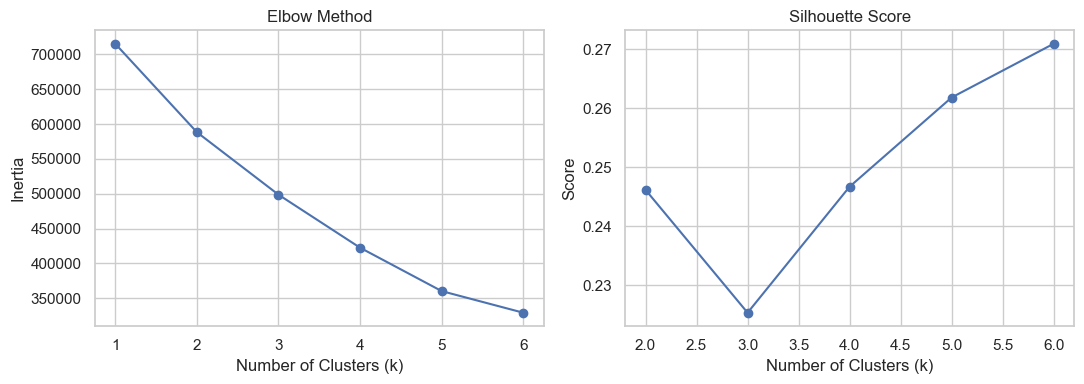

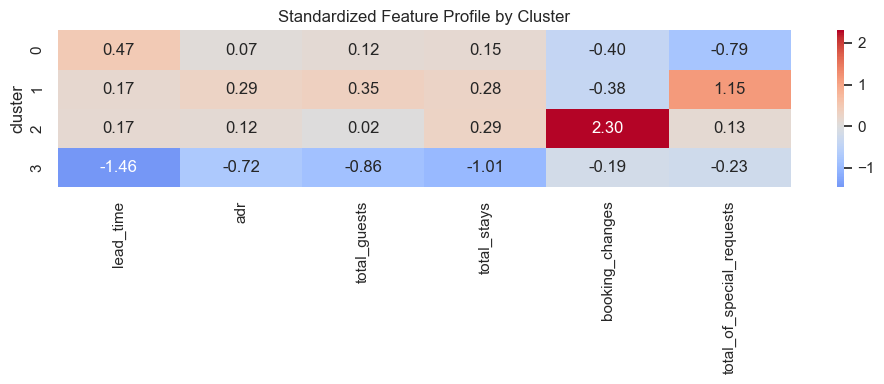

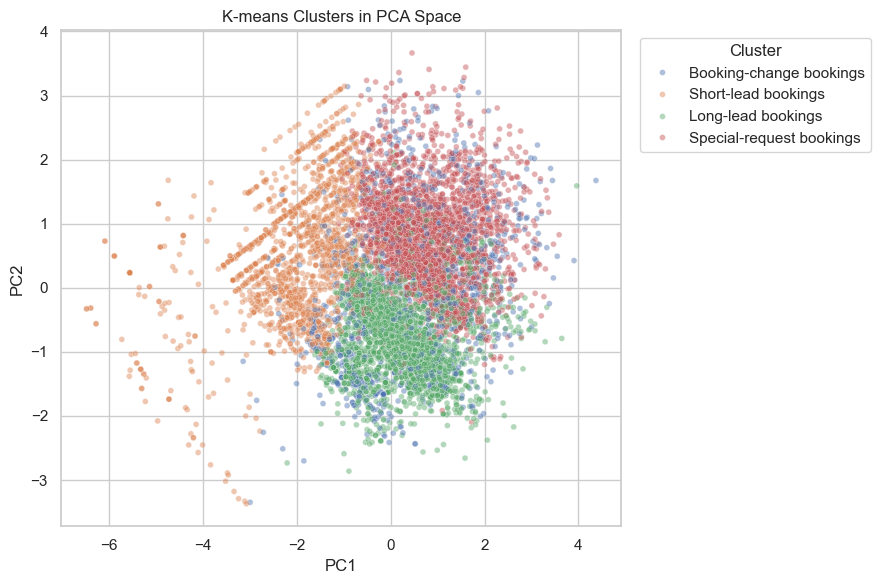

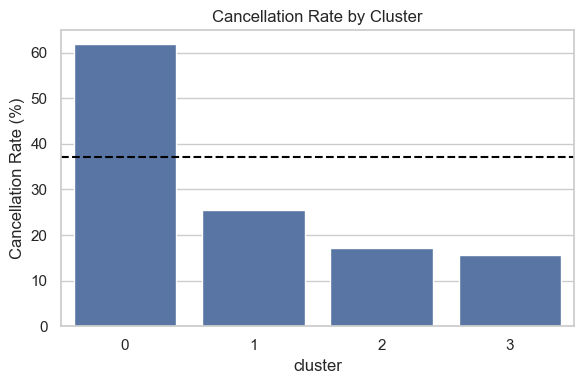

In [5]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
df = load_cleaned_data()

cluster_features = [
    "lead_time",
    "adr",
    "total_guests",
    "total_stays",
    "booking_changes",
    "total_of_special_requests",
]

# K-means is suitable for scalable and interpretable numeric booking segments.
X_scaled = StandardScaler().fit_transform(np.log1p(df[cluster_features]))

evaluation_rows = []
for k in range(1, 7):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_scaled)
    evaluation_rows.append(
        {
            "number_of_clusters": k,
            "inertia": model.inertia_,
            "silhouette_score": (
                np.nan
                if k == 1
                else silhouette_score(
                    X_scaled, labels, sample_size=10_000, random_state=RANDOM_STATE
                )
            ),
            "smallest_cluster_percentage": (
                pd.Series(labels).value_counts(normalize=True).min() * 100
            ),
        }
    )

evaluation = pd.DataFrame(evaluation_rows)
candidates = evaluation[
    (evaluation["number_of_clusters"] >= 2)
    & (evaluation["smallest_cluster_percentage"] >= 10)
]
number_of_clusters = int(
    candidates.loc[candidates["silhouette_score"].idxmax(), "number_of_clusters"]
)

df["cluster"] = KMeans(
    n_clusters=number_of_clusters, random_state=RANDOM_STATE, n_init=10
).fit_predict(X_scaled)

cluster_summary = df.groupby("cluster")[
    cluster_features + ["is_family", "is_canceled"]
].mean()
cluster_summary = cluster_summary.rename(
    columns={"is_family": "family_booking_rate", "is_canceled": "cancellation_rate"}
)
cluster_summary["booking_count"] = df.groupby("cluster").size()
cluster_summary["booking_percentage"] = cluster_summary["booking_count"] / len(df) * 100
cluster_summary[["family_booking_rate", "cancellation_rate"]] *= 100

# Cluster labels are arbitrary, so names are assigned from observed profiles.
cluster_names = {}
unlabeled_clusters = set(cluster_summary.index)
naming_rules = [
    ("booking_changes", "idxmax", "Booking-change bookings"),
    ("total_of_special_requests", "idxmax", "Special-request bookings"),
    ("lead_time", "idxmax", "Long-lead bookings"),
    ("lead_time", "idxmin", "Short-lead bookings"),
]
for column, selector, name in naming_rules:
    if not unlabeled_clusters:
        break
    values = cluster_summary.loc[list(unlabeled_clusters), column]
    cluster = getattr(values, selector)()
    cluster_names[cluster] = name
    unlabeled_clusters.remove(cluster)

for cluster in unlabeled_clusters:
    cluster_names[cluster] = f"Booking segment {cluster}"

cluster_summary.insert(
    0,
    "cluster_name",
    [cluster_names[cluster] for cluster in cluster_summary.index],
)

print("Cluster number evaluation")
print(evaluation.round(4).to_string(index=False))
print("\nSelected number of clusters:", number_of_clusters)
print("\nCluster summary")
print(cluster_summary.round(2).to_string())
print("\nCluster interpretation")
for cluster, name in cluster_names.items():
    print(f"- Cluster {cluster}: {name}")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(evaluation["number_of_clusters"], evaluation["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(
    evaluation["number_of_clusters"].iloc[1:],
    evaluation["silhouette_score"].iloc[1:],
    marker="o",
)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

scaled_profile = pd.DataFrame(X_scaled, columns=cluster_features)
scaled_profile["cluster"] = df["cluster"].to_numpy()
plt.figure(figsize=(10, 4))
sns.heatmap(
    scaled_profile.groupby("cluster").mean(),
    annot=True,
    center=0,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Standardized Feature Profile by Cluster")
plt.tight_layout()
plt.show()

pca_coordinates = PCA(n_components=2).fit_transform(X_scaled)
pca_plot = pd.DataFrame(pca_coordinates, columns=["PC1", "PC2"])
pca_plot["cluster"] = df["cluster"].to_numpy()
pca_plot["cluster_name"] = pca_plot["cluster"].map(cluster_names)
pca_plot = pca_plot.sample(n=min(10_000, len(pca_plot)), random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_plot,
    x="PC1",
    y="PC2",
    hue="cluster_name",
    alpha=0.45,
    s=18,
)
plt.title("K-means Clusters in PCA Space")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=cluster_summary.reset_index(), x="cluster", y="cancellation_rate")
plt.axhline(df["is_canceled"].mean() * 100, color="black", linestyle="--")
plt.title("Cancellation Rate by Cluster")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()


## 5. Preprocessing and Model Parameter Comparison

In [6]:
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier


def compare_booking_models(
    cleaned_df,
    target_column="is_canceled",
    cv_splits=5,
    sample_size=None,
    random_state=42,
):
    """Compare preprocessing and classification model combinations."""
    data = take_stratified_sample(cleaned_df, sample_size, random_state)
    X = data.drop(columns=target_column)
    y = data[target_column]

    categorical_columns = X.select_dtypes(include=["object", "string"]).columns.tolist()
    numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()

    scalers = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler()}
    encoders = {
        "OneHotEncoder": OneHotEncoder(handle_unknown="ignore"),
        "OrdinalEncoder": OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1
        ),
    }
    models = [
        (
            "Logistic Regression",
            "C=0.1, class_weight=balanced",
            LogisticRegression(
                C=0.1, class_weight="balanced", solver="liblinear", max_iter=2000
            ),
        ),
        (
            "Logistic Regression",
            "C=1.0, class_weight=balanced",
            LogisticRegression(
                C=1.0, class_weight="balanced", solver="liblinear", max_iter=2000
            ),
        ),
        (
            "Decision Tree",
            "max_depth=3, class_weight=balanced",
            DecisionTreeClassifier(
                max_depth=3, class_weight="balanced", random_state=random_state
            ),
        ),
        (
            "Decision Tree",
            "max_depth=5, class_weight=balanced",
            DecisionTreeClassifier(
                max_depth=5, class_weight="balanced", random_state=random_state
            ),
        ),
        (
            "Decision Tree",
            "max_depth=8, class_weight=balanced",
            DecisionTreeClassifier(
                max_depth=8, class_weight="balanced", random_state=random_state
            ),
        ),
        ("K-Nearest Neighbors", "n_neighbors=5", KNeighborsClassifier(n_neighbors=5)),
        (
            "K-Nearest Neighbors",
            "n_neighbors=11",
            KNeighborsClassifier(n_neighbors=11),
        ),
        (
            "K-Nearest Neighbors",
            "n_neighbors=21",
            KNeighborsClassifier(n_neighbors=21),
        ),
    ]

    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
    results = []

    for scaler_name, scaler in scalers.items():
        for encoder_name, encoder in encoders.items():
            preprocessor = ColumnTransformer(
                [
                    (
                        "numeric",
                        Pipeline(
                            [
                                ("imputer", SimpleImputer(strategy="median")),
                                ("scaler", scaler),
                            ]
                        ),
                        numerical_columns,
                    ),
                    (
                        "categorical",
                        Pipeline(
                            [
                                ("imputer", SimpleImputer(strategy="most_frequent")),
                                ("encoder", encoder),
                            ]
                        ),
                        categorical_columns,
                    ),
                ]
            )

            for model_name, parameters, model in models:
                fold_results = []
                for train_index, test_index in cv.split(X, y):
                    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
                    pipeline.fit(X.iloc[train_index], y.iloc[train_index])
                    prediction = pipeline.predict(X.iloc[test_index])
                    actual = y.iloc[test_index]
                    fold_results.append(
                        {
                            "accuracy": accuracy_score(actual, prediction),
                            "balanced_accuracy": balanced_accuracy_score(actual, prediction),
                            "precision": precision_score(actual, prediction, zero_division=0),
                            "recall": recall_score(actual, prediction, zero_division=0),
                            "f1_score": f1_score(actual, prediction, zero_division=0),
                        }
                    )

                scores = pd.DataFrame(fold_results).mean()
                results.append(
                    {
                        "scaling": scaler_name,
                        "encoding": encoder_name,
                        "model": model_name,
                        "parameters": parameters,
                        **scores.to_dict(),
                    }
                )

    return (
        pd.DataFrame(results)
        .sort_values(["f1_score", "balanced_accuracy"], ascending=False)
        .reset_index(drop=True)
    )


if __name__ == "__main__":
    results = compare_booking_models(load_cleaned_data(), sample_size=10_000)
    print("Top five combinations based on F1-score")
    print(results.head(5).round(4).to_string(index=False))


Top five combinations based on F1-score
       scaling      encoding               model                         parameters  accuracy  balanced_accuracy  precision  recall  f1_score
  MinMaxScaler OneHotEncoder       Decision Tree max_depth=8, class_weight=balanced    0.8203             0.8182     0.7372  0.8099    0.7693
StandardScaler OneHotEncoder       Decision Tree max_depth=8, class_weight=balanced    0.8202             0.8181     0.7370  0.8099    0.7692
StandardScaler OneHotEncoder Logistic Regression       C=1.0, class_weight=balanced    0.8157             0.8123     0.7297  0.7993    0.7628
StandardScaler OneHotEncoder Logistic Regression       C=0.1, class_weight=balanced    0.8156             0.8120     0.7299  0.7983    0.7625
  MinMaxScaler OneHotEncoder Logistic Regression       C=1.0, class_weight=balanced    0.8103             0.8074     0.7215  0.7961    0.7568
